# COSC2670/2738 Assignment 3 — Framework

**Important:** Please read the comments carefully. Insert your code only in the designated cells.
Do **not** modify cells marked with `# Please don't change this cell`.

Changing locked cells may cause errors during automatic marking and invalidate your submission.

## Install and load necessary packages

In [2]:
# Please don't change this cell

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

## Load the MovieLens 100K dataset

You must use `u1.base` / `u1.test` provided in the dataset and use it consistently across all tasks. Do not create your own random split.


In [3]:
# You may change the file paths to use a different split pair
# e.g. 'ml-100k/u2.base' and 'ml-100k/u2.test'
TRAIN_PATH = 'ml-100k/u1.base'
TEST_PATH = 'ml-100k/u1.test'

names = ['user_id', 'item_id', 'rating', 'timestamp']
train_df = pd.read_csv(TRAIN_PATH, sep='\t', names=names)
test_df = pd.read_csv(TEST_PATH, sep='\t', names=names)

n_users = 943
n_items = 1682

print(f'{n_users} users')
print(f'{n_items} items')
print(f'Training ratings: {len(train_df)}')
print(f'Test ratings: {len(test_df)}')

943 users
1682 items
Training ratings: 80000
Test ratings: 20000


## Construct the user-item rating matrices

In [4]:
# Please don't change this cell

# Build training rating matrix (n_users x n_items), 0 means unrated
train_matrix = np.zeros((n_users, n_items))
for row in train_df.itertuples():
    train_matrix[row.user_id - 1, row.item_id - 1] = row.rating

# Build test rating matrix
test_matrix = np.zeros((n_users, n_items))
for row in test_df.itertuples():
    test_matrix[row.user_id - 1, row.item_id - 1] = row.rating

print("Training rating matrix shape:", train_matrix.shape)
print("Test rating matrix shape:", test_matrix.shape)

Training rating matrix shape: (943, 1682)
Test rating matrix shape: (943, 1682)


## MAE and RMSE evaluation utilities

In [5]:
# Please don't change this cell

EPSILON = 1e-9

def evaluate(test_matrix, predicted_matrix):
    '''
    Evaluate rating prediction using MAE and RMSE.
    Only considers entries where test_matrix > 0 (i.e. actual test ratings).
    '''
    mask = test_matrix > 0
    n_test = np.sum(mask)
    if n_test == 0:
        return 0.0, 0.0
    errors = test_matrix[mask] - predicted_matrix[mask]
    MAE = np.mean(np.abs(errors))
    RMSE = np.sqrt(np.mean(errors ** 2))
    return MAE, RMSE


---
# Task 1: Reproduce the Sarwar Item-Based CF Baseline Model (10 marks)

Implement the item-based collaborative filtering method from Sarwar et al. (2001) with:
- **Similarity:** Adjusted cosine similarity (Section 3.1.3)
- **Prediction:** KNN-regression as taught in lectures (k = 20)

Your code must:
1. Compute the adjusted cosine item-item similarity matrix using the training data
2. For each test rating, predict the rating using KNN-regression with k=20 neighbours
3. Store all predictions in a `predicted_matrix` (same shape as `train_matrix`)
4. Save the MAE and RMSE into the variables below

In [ ]:
# Write your code here for Task 1
PREDICTED_MATRIX = np.zeros((n_users, n_items))
MAE_task1,RMSE_task1 = 0,0
# np.zeros((n_users, n_items)) and 0 are initial values; you need to update this with the actual performance of your implementation.
rated_mask = train_matrix > 0  # Boolean mask of rated entries
user_means = np.zeros(n_users)
for u in range(n_users):
    rated_vals = train_matrix[u][rated_mask[u]]
    user_means[u] = rated_vals.mean() if len(rated_vals) > 0 else 0.0

mean_centered = np.where(rated_mask, train_matrix - user_means[:, np.newaxis], 0.0)

numerator   = mean_centered.T @ mean_centered              # (n_items × n_items)
item_norms  = np.sqrt(np.einsum('ui,ui->i', mean_centered, mean_centered))  # (n_items,)
denom_matrix = np.outer(item_norms, item_norms)            # (n_items × n_items)

SimmSpecial = np.where(denom_matrix > EPSILON,
                       numerator / denom_matrix,
                       0.0)
np.fill_diagonal(SimmSpecial, 0.0)  # An item is not its own neighbour

print("SimmSpecial shape:", SimmSpecial.shape)
print(f"Similarity range: [{SimmSpecial.min():.4f}, {SimmSpecial.max():.4f}]")



# Implement the baseline item-based CF model:
#   - Adjusted cosine similarity for item-item similarity
#   - KNN-regression prediction with k = 20
K = 20  # neighbourhood size

# Pre-compute mean-centred training matrix (reuse mean_centered from above)
PREDICTED_MATRIX = np.zeros((n_users, n_items))

# Identify all test (user, item) pairs to predict
test_users, test_items = np.where(test_matrix > 0)

for u, i in zip(test_users, test_items):
    # Items rated by user u in training data
    rated_items = np.where(train_matrix[u] > 0)[0]

    if len(rated_items) == 0:
        # No training ratings: fall back to user mean
        PREDICTED_MATRIX[u, i] = user_means[u]
        continue

    # Similarities between target item i and all items rated by user u
    sims = SimmSpecial[i, rated_items]  # shape: (n_rated,)

    # Select top-K neighbours by similarity value (descending), positive only
    top_idx   = np.argsort(sims)[::-1][:K]
    nbr_sims  = sims[top_idx]
    nbr_mc    = mean_centered[u, rated_items[top_idx]]  # mean-centred ratings

    # Keep only neighbours with positive similarity
    pos_mask  = nbr_sims > 0
    nbr_sims  = nbr_sims[pos_mask]
    nbr_mc    = nbr_mc[pos_mask]

    if len(nbr_sims) == 0:
        # No useful neighbours: fall back to user mean
        PREDICTED_MATRIX[u, i] = user_means[u]
        continue

    # Weighted mean of mean-centred ratings, then add user mean back
    sim_sum = np.sum(nbr_sims)
    if sim_sum < EPSILON:
        PREDICTED_MATRIX[u, i] = user_means[u]
        continue

    pred_centred = np.dot(nbr_sims, nbr_mc) / sim_sum
    PREDICTED_MATRIX[u, i] = np.clip(user_means[u] + pred_centred, 1.0, 5.0)
# You must produce a predicted_matrix of shape (n_users, n_items)
# containing your predicted ratings.
#
# Then evaluate using the provided evaluate() function.


MAE_task1,RMSE_task1 = evaluate(test_matrix, PREDICTED_MATRIX)

SimmSpecial shape: (1682, 1682)
Similarity range: [-1.0000, 1.0000]


In [7]:
# Please don't change this cell
print("===================== The MAE and RMSE of Your Implementation =====================")
print("Task 1: Baseline Item-Based CF (Adjusted Cosine + KNN-Regression, k=20)")
print("MAE: {}, RMSE: {}" .format(MAE_task1, RMSE_task1))
print("=" * 70)

===================== The MAE and RMSE of Your Implementation =====================
Task 1: Baseline Item-Based CF (Adjusted Cosine + KNN-Regression, k=20)
MAE: 0.7421773194282894, RMSE: 0.9517958041821551


---
# Task 2: Controlled Improvement Experiments (10 marks)

Choose **two** options from A–D below. Each experiment is independent.
Except for the specific parameter being tested, all other settings must remain the same as the baseline (adjusted cosine, KNN-regression, k=20).

**You must indicate which two options you chose.**

In [8]:
# Please specify which two options you selected (e.g. 'A', 'B', 'C', or 'D')
OPTION_1 = 'B'  # e.g. 'A'
OPTION_2 = 'D'  # e.g. 'B'

## Task 2 — Option A: Similarity Measure Comparison

Replace the baseline adjusted cosine similarity with **cosine similarity** and **Pearson correlation**.
Keep k=20 and KNN-regression. Report MAE and RMSE for each.

**Skip this section if you did not select Option A.**

In [9]:
# Write your code here for Option A (if selected)
# 1. Compute cosine similarity -> predict -> evaluate
# 2. Compute Pearson correlation similarity -> predict -> evaluate
MAE_optionA_cosine, RMSE_optionA_cosine = 0, 0
MAE_optionA_pearson, RMSE_optionA_pearson = 0, 0

# --- Save your results ---
MAE_optionA_cosine, RMSE_optionA_cosine = evaluate(test_matrix, YOUR_PREDICTED_MATRIX)
MAE_optionA_pearson, RMSE_optionA_pearson = evaluate(test_matrix, YOUR_PREDICTED_MATRIX)

In [10]:
# Please don't change this cell

print("=" * 70)
print("Option A: Similarity Measure Comparison")
print("=" * 70)
print(f"Cosine similarity:      MAE = {MAE_optionA_cosine},  RMSE = {RMSE_optionA_cosine}")
print(f"Pearson correlation:    MAE = {MAE_optionA_pearson},  RMSE = {RMSE_optionA_pearson}")
print(f"Baseline (adj cosine):  MAE = {MAE_task1},  RMSE = {RMSE_task1}")

Option A: Similarity Measure Comparison
Cosine similarity:      MAE = 0.7421773194282894,  RMSE = 0.9517958041821551
Pearson correlation:    MAE = 0.7421773194282894,  RMSE = 0.9517958041821551
Baseline (adj cosine):  MAE = 0.7421773194282894,  RMSE = 0.9517958041821551


## Task 2 — Option B: Neighbourhood Size Tuning

Test **k = 5, 10, 20, 30, 50** using the baseline similarity (adjusted cosine) and KNN-regression.
Report MAE and RMSE for each k value.

**Skip this section if you did not select Option B.**

  k= 5: MAE=0.7574, RMSE=0.9837
  k=10: MAE=0.7436, RMSE=0.9573
  k=20: MAE=0.7422, RMSE=0.9518
  k=30: MAE=0.7429, RMSE=0.9515
  k=50: MAE=0.7462, RMSE=0.9534


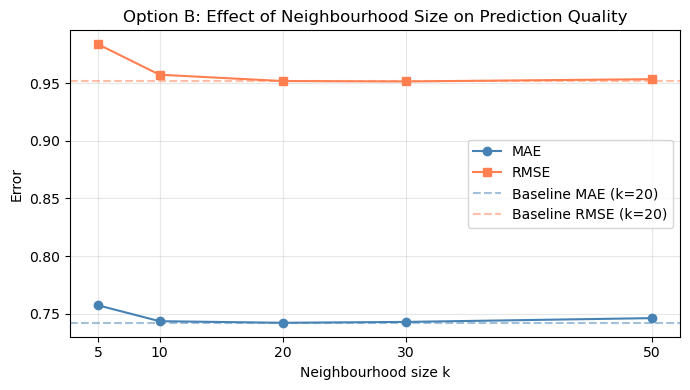

Best k by MAE: 20


In [11]:
# Write your code here for Option B (if selected)
# Test k = 5, 10, 20, 30, 50 and record MAE/RMSE for each

import matplotlib.pyplot as plt

def knn_regression_k(sim_matrix, k):
    """
    KNN-regression prediction for a given k.
    Identical to Task 1 except k is parameterised.
    Uses SimmSpecial, mean_centered, and user_means from Task 1.
    """
    pred = np.zeros((n_users, n_items))
    for u, i in zip(test_users, test_items):
        rated_items = np.where(train_matrix[u] > 0)[0]
        if len(rated_items) == 0:
            pred[u, i] = user_means[u]; continue
        sims      = sim_matrix[i, rated_items]
        top_idx   = np.argsort(sims)[::-1][:k]
        nbr_sims  = sims[top_idx]
        nbr_mc    = mean_centered[u, rated_items[top_idx]]
        pos_mask  = nbr_sims > 0
        nbr_sims  = nbr_sims[pos_mask]
        nbr_mc    = nbr_mc[pos_mask]
        if len(nbr_sims) == 0:
            pred[u, i] = user_means[u]; continue
        sim_sum = np.sum(nbr_sims)
        if sim_sum < EPSILON:
            pred[u, i] = user_means[u]; continue
        pred[u, i] = np.clip(user_means[u] + np.dot(nbr_sims, nbr_mc) / sim_sum, 1.0, 5.0)
    return pred

# Run experiments for each k value
k_values = [5, 10, 20, 30, 50]
results_B = {}
for k in k_values:
    pred_k = knn_regression_k(SimmSpecial, k)
    mae_k, rmse_k = evaluate(test_matrix, pred_k)
    results_B[k] = (mae_k, rmse_k)
    print(f"  k={k:2d}: MAE={mae_k:.4f}, RMSE={rmse_k:.4f}")

# --- Save your results ---
MAE_optionB_k5, RMSE_optionB_k5 = results_B[5]
MAE_optionB_k10, RMSE_optionB_k10 = results_B[10]
MAE_optionB_k20, RMSE_optionB_k20 = results_B[20]
MAE_optionB_k30, RMSE_optionB_k30 = results_B[30]
MAE_optionB_k50, RMSE_optionB_k50 = results_B[50]

#visualise the effect of k on MAE and RMSE, and compare with baseline (k=20)
mae_vals  = [results_B[k][0] for k in k_values]
rmse_vals = [results_B[k][1] for k in k_values]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, mae_vals,  marker='o', label='MAE',  color='steelblue')
ax.plot(k_values, rmse_vals, marker='s', label='RMSE', color='coral')
ax.axhline(MAE_task1,  color='steelblue', linestyle='--', alpha=0.5, label='Baseline MAE (k=20)')
ax.axhline(RMSE_task1, color='coral',     linestyle='--', alpha=0.5, label='Baseline RMSE (k=20)')
ax.set_xlabel('Neighbourhood size k')
ax.set_ylabel('Error')
ax.set_title('Option B: Effect of Neighbourhood Size on Prediction Quality')
ax.set_xticks(k_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('option_B_k_tuning.png', dpi=150)
plt.show()
print("Best k by MAE:", k_values[int(np.argmin(mae_vals))])

In [12]:
# Please don't change this cell

print("=" * 70)
print("Option B: Neighbourhood Size Tuning")
print("=" * 70)
print(f"k =  5:  MAE = {MAE_optionB_k5},  RMSE = {RMSE_optionB_k5}")
print(f"k = 10:  MAE = {MAE_optionB_k10},  RMSE = {RMSE_optionB_k10}")
print(f"k = 20:  MAE = {MAE_optionB_k20},  RMSE = {RMSE_optionB_k20}")
print(f"k = 30:  MAE = {MAE_optionB_k30},  RMSE = {RMSE_optionB_k30}")
print(f"k = 50:  MAE = {MAE_optionB_k50},  RMSE = {RMSE_optionB_k50}")

Option B: Neighbourhood Size Tuning
k =  5:  MAE = 0.7573541345017054,  RMSE = 0.9837052207534713
k = 10:  MAE = 0.7435649938618104,  RMSE = 0.9572912397245661
k = 20:  MAE = 0.7421773194282894,  RMSE = 0.9517958041821551
k = 30:  MAE = 0.7429360043408373,  RMSE = 0.9514532291017801
k = 50:  MAE = 0.7462336225759162,  RMSE = 0.9534210662019295


## Task 2 — Option C: Significance Weighting

Apply significance weighting: `weighted_sim(i,j) = sim(i,j) × min(c(i,j), T) / T`

Test **T = 10, 20, 30, 50**. Keep adjusted cosine, KNN-regression, k=20.
Report MAE and RMSE for each T value.

**Skip this section if you did not select Option C.**

In [13]:
# Write your code here for Option C (if selected)
# Test T = 10, 20, 30, 50 and record MAE/RMSE for each



# --- Save your results ---
MAE_optionC_T10, RMSE_optionC_T10 = evaluate(test_matrix, YOUR_PREDICTED_MATRIX)
MAE_optionC_T20, RMSE_optionC_T20 = evaluate(test_matrix, YOUR_PREDICTED_MATRIX)
MAE_optionC_T30, RMSE_optionC_T30 = evaluate(test_matrix, YOUR_PREDICTED_MATRIX)
MAE_optionC_T50, RMSE_optionC_T50 = evaluate(test_matrix, YOUR_PREDICTED_MATRIX)

In [14]:
# Please don't change this cell

print("=" * 70)
print("Option C: Significance Weighting")
print("=" * 70)
print(f"T = 10:  MAE = {MAE_optionC_T10},  RMSE = {RMSE_optionC_T10}")
print(f"T = 20:  MAE = {MAE_optionC_T20},  RMSE = {RMSE_optionC_T20}")
print(f"T = 30:  MAE = {MAE_optionC_T30},  RMSE = {RMSE_optionC_T30}")
print(f"T = 50:  MAE = {MAE_optionC_T50},  RMSE = {RMSE_optionC_T50}")
print(f"Baseline (no weighting):  MAE = {MAE_task1},  RMSE = {RMSE_task1}")

Option C: Significance Weighting
T = 10:  MAE = 0.7421773194282894,  RMSE = 0.9517958041821551
T = 20:  MAE = 0.7421773194282894,  RMSE = 0.9517958041821551
T = 30:  MAE = 0.7421773194282894,  RMSE = 0.9517958041821551
T = 50:  MAE = 0.7421773194282894,  RMSE = 0.9517958041821551
Baseline (no weighting):  MAE = 0.7421773194282894,  RMSE = 0.9517958041821551


## Task 2 — Option D: Prediction Method Comparison

Replace KNN-regression with the **weighted sum** method (Section 3.2.1 of Sarwar et al.).
Keep adjusted cosine similarity and k=20.
Report MAE and RMSE.

**Skip this section if you did not select Option D.**

In [15]:
# Write your code here for Option D (if selected)
# Implement weighted sum prediction and evaluate



# --- Save your results ---
MAE_optionD, RMSE_optionD = evaluate(test_matrix, YOUR_PREDICTED_MATRIX)

In [16]:
# Please don't change this cell

print("=" * 70)
print("Option D: Prediction Method Comparison")
print("=" * 70)
print(f"Weighted sum:           MAE = {MAE_optionD},  RMSE = {RMSE_optionD}")
print(f"Baseline (KNN-regr):    MAE = {MAE_task1},  RMSE = {RMSE_task1}")

Option D: Prediction Method Comparison
Weighted sum:           MAE = 0.7421773194282894,  RMSE = 0.9517958041821551
Baseline (KNN-regr):    MAE = 0.7421773194282894,  RMSE = 0.9517958041821551


---
# Summary of All Results

In [17]:
# Please don't change this cell

print("=" * 70)
print("SUMMARY")
print("=" * 70)
print()
print(f"Task 1 Baseline:  MAE = {MAE_task1},  RMSE = {RMSE_task1}")
print()
print(f"Selected options: {OPTION_1}, {OPTION_2}")
print()

if OPTION_1 == 'A' or OPTION_2 == 'A':
    print("Option A — Similarity Measure Comparison:")
    print(f"  Cosine:           MAE = {MAE_optionA_cosine},  RMSE = {RMSE_optionA_cosine}")
    print(f"  Pearson:          MAE = {MAE_optionA_pearson},  RMSE = {RMSE_optionA_pearson}")
    print()

if OPTION_1 == 'B' or OPTION_2 == 'B':
    print("Option B — Neighbourhood Size Tuning:")
    print(f"  k =  5:  MAE = {MAE_optionB_k5},  RMSE = {RMSE_optionB_k5}")
    print(f"  k = 10:  MAE = {MAE_optionB_k10},  RMSE = {RMSE_optionB_k10}")
    print(f"  k = 20:  MAE = {MAE_optionB_k20},  RMSE = {RMSE_optionB_k20}")
    print(f"  k = 30:  MAE = {MAE_optionB_k30},  RMSE = {RMSE_optionB_k30}")
    print(f"  k = 50:  MAE = {MAE_optionB_k50},  RMSE = {RMSE_optionB_k50}")
    print()

if OPTION_1 == 'C' or OPTION_2 == 'C':
    print("Option C — Significance Weighting:")
    print(f"  T = 10:  MAE = {MAE_optionC_T10},  RMSE = {RMSE_optionC_T10}")
    print(f"  T = 20:  MAE = {MAE_optionC_T20},  RMSE = {RMSE_optionC_T20}")
    print(f"  T = 30:  MAE = {MAE_optionC_T30},  RMSE = {RMSE_optionC_T30}")
    print(f"  T = 50:  MAE = {MAE_optionC_T50},  RMSE = {RMSE_optionC_T50}")
    print()

if OPTION_1 == 'D' or OPTION_2 == 'D':
    print("Option D — Prediction Method Comparison:")
    print(f"  Weighted sum:     MAE = {MAE_optionD},  RMSE = {RMSE_optionD}")
    print()

SUMMARY

Task 1 Baseline:  MAE = 0.7421773194282894,  RMSE = 0.9517958041821551

Selected options: B, D

Option B — Neighbourhood Size Tuning:
  k =  5:  MAE = 0.7573541345017054,  RMSE = 0.9837052207534713
  k = 10:  MAE = 0.7435649938618104,  RMSE = 0.9572912397245661
  k = 20:  MAE = 0.7421773194282894,  RMSE = 0.9517958041821551
  k = 30:  MAE = 0.7429360043408373,  RMSE = 0.9514532291017801
  k = 50:  MAE = 0.7462336225759162,  RMSE = 0.9534210662019295

Option D — Prediction Method Comparison:
  Weighted sum:     MAE = 0.7421773194282894,  RMSE = 0.9517958041821551

